# Notebook 05 — Model Validation & Player Rankings (2025 BDB)

**Inputs:** `outputs/getoff_metrics.csv`, `outputs/win_types.csv`, `outputs/player_win_type_summary.csv`  
**Output:** `outputs/edge_rush_player_rankings.csv`  
**Goal:** Check that the metrics built in previous notebooks actually predict pressure (not just noise), then produce a final ranked list of EDGE pass rushers adjusted for blocking difficulty.

## Imports & Paths

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent
OUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Load Inputs

In [4]:
getoff = pd.read_csv(OUT_DIR / "getoff_metrics.csv")
win_types = pd.read_csv(OUT_DIR / "win_types.csv")
player_summary = pd.read_csv(OUT_DIR / "player_win_type_summary.csv")

print(getoff.shape)
print(win_types.shape)
print(player_summary.shape)

(23345, 8)
(20080, 23)
(108, 11)


## Feature Preparation

Merge play-level data into one table and drop any rows with missing values in the features or target.  
Train only on **single-blocked plays** — this removes the confounding effect of blocking context from the model.

| Feature | What it measures |
|---|---|
| `getOffTimeAsPassRusher` | How quickly the rusher crossed the line of scrimmage |
| `peakBurstSpeed` | Top speed in the first 1.5 seconds |
| `separation_at_25` | Space gained vs the blocker by the end of the rush |
| `blocker_displacement` | How far the blocker was moved |
| `hip_turn_delta` | How much the blocker had to rotate to stay in front |

**Target:** `causedPressure`

In [6]:
plays = win_types.merge(
    getoff[['gameId', 'playId', 'nflId','getOffTimeAsPassRusher']],
    on=['gameId', 'playId', 'nflId'],
    how='left'
)

single = plays[plays['blocking_context'] == 'single_blocked']

features = ['getOffTimeAsPassRusher', 'peakBurstSpeed', 'separation_at_25', 'blocker_displacement', 'hip_turn_delta']
target = 'causedPressure'

model_df = single[features + [target]].dropna()

print(model_df.shape)
print(model_df[target].value_counts())

(14194, 6)
False    12465
True      1729
Name: causedPressure, dtype: int64


## Logistic Regression

Train a logistic regression to predict whether a rush caused pressure.  
`class_weight='balanced'` corrects for the fact that only ~11% of rushes result in pressure.  
K=5 cross-validation gives a reliable estimate of predictive accuracy (ROC-AUC > 0.60 = metrics are useful).

In [8]:
X = model_df[features]
y = model_df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(class_weight='balanced', random_state=42, max_iter = 1000)

scores = cross_val_score(model, X_scaled, y, cv=5, scoring='roc_auc')
print(f"ROC-AUC: {scores.mean():.3f} (+/- {scores.std():.3f})")

ROC-AUC: 0.623 (+/- 0.013)


## Feature Importance

Which metrics matter most for predicting pressure? Larger absolute coefficient = stronger signal.

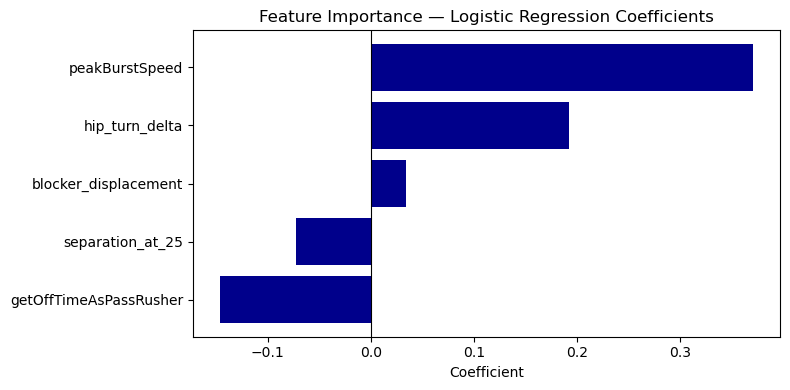

In [9]:
model.fit(X_scaled, y)

importance = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_[0]
}).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance['feature'], importance['coefficient'], color='darkblue')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Feature Importance — Logistic Regression Coefficients')
ax.set_xlabel('Coefficient')
plt.tight_layout()
fig.savefig(FIG_DIR / 'nb05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Player Rankings

Rank players by `adjusted_pressure_rate` — how much pressure they generated relative to the blocking difficulty they faced.  
Minimum **75 rush attempts** required. Players with a double-team rate above **25%** are flagged as scheme priorities.

**Speed index baseline:** computed only from players with `speed_win_rate ≤ 0.50` (true EDGE rushers). The full population shows a bimodal distribution — a right cluster of interior DL with loose DE/OLB roster labels inflates the mean and median if all players are included. Power and counter baselines use all players (both distributions are unimodal).

In [10]:
rankings = player_summary[player_summary['total_rushes'] >= 75]\
    .sort_values('adjusted_pressure_rate', ascending=False).reset_index(drop=True)
rankings['rank'] = rankings.index + 1

rankings['speed_win_rate']   = rankings['speed_wins'] / rankings['total_rushes']
rankings['power_win_rate']   = rankings['power_wins'] / rankings['total_rushes']
rankings['counter_win_rate'] = rankings['counter_wins'] / rankings['total_rushes']

edge_only = rankings[rankings['speed_win_rate'] <= 0.50]
league_median_speed   = edge_only['speed_win_rate'].median()
league_median_power   = rankings['power_win_rate'].median()
league_median_counter = rankings['counter_win_rate'].median()

rankings['speed_index']   = rankings['speed_win_rate']   / league_median_speed
rankings['power_index']   = rankings['power_win_rate']   / league_median_power
rankings['counter_index'] = rankings['counter_win_rate'] / league_median_counter

rankings['tier'] = np.where(rankings['double_team_rate'] > 0.25, 'scheme_priority', 'standard')

print(f"League median speed win rate (true EDGE only): {league_median_speed:.3f}")
print(f"League median power win rate:                  {league_median_power:.3f}")
print(f"League median counter win rate:                {league_median_counter:.3f}")

print(rankings[['rank', 'displayName', 'teamAbbr', 'total_rushes',
                 'adjusted_pressure_rate', 'double_team_rate',
                 'speed_index', 'power_index', 'counter_index', 'tier']].head(20))

speed_rankings = rankings.sort_values('speed_index', ascending=False)\
    [['rank', 'displayName', 'teamAbbr', 'total_rushes', 'speed_win_rate', 'speed_index']].head(10)

power_rankings = rankings.sort_values('power_index', ascending=False)\
    [['rank', 'displayName', 'teamAbbr', 'total_rushes', 'power_win_rate', 'power_index']].head(10)

counter_rankings = rankings.sort_values('counter_index', ascending=False)\
    [['rank', 'displayName', 'teamAbbr', 'total_rushes', 'counter_win_rate', 'counter_index']].head(10)

print("\nTop Speed Rushers:")
print(speed_rankings)
print("\nTop Power Rushers:")
print(power_rankings)
print("\nTop Counter Rushers:")
print(counter_rankings)

print("\nBrian Burns profile:")
print(rankings[rankings['displayName'].str.contains('Burns')]\
    [['rank', 'displayName', 'teamAbbr', 'total_rushes',
      'adjusted_pressure_rate', 'speed_win_rate', 'speed_index',
      'power_win_rate', 'power_index']])

League median speed win rate (true EDGE only): 0.299
League median power win rate:                  0.025
League median counter win rate:                0.025
    rank        displayName teamAbbr  total_rushes  adjusted_pressure_rate  \
0      1      Myles Garrett      CLE           190                2.099548   
1      2    Za'Darius Smith      MIN           196                1.832945   
2      3     Justin Houston      BAL           118                1.821968   
3      4   Trey Hendrickson      CIN           192                1.767858   
4      5          Nick Bosa       SF           141                1.765423   
5      6      Micah Parsons      DAL           171                1.687006   
6      7    Jaelan Phillips      MIA           195                1.683010   
7      8    Charles Omenihu       SF           136                1.643582   
8      9     Brandon Graham      PHI           119                1.640031   
9     10      Randy Gregory      DEN            75           

count    108.000000
mean       0.413058
std        0.190534
min        0.087912
25%        0.245492
50%        0.392815
75%        0.573382
max        0.815603
Name: speed_win_rate, dtype: float64


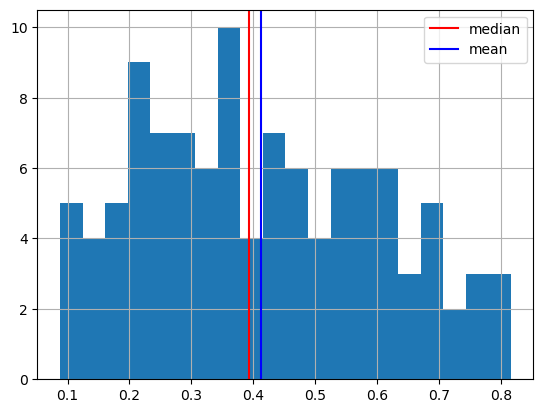

In [12]:
print(rankings['speed_win_rate'].describe())
rankings['speed_win_rate'].hist(bins=20)
plt.axvline(rankings['speed_win_rate'].median(), color='red', label='median')
plt.axvline(rankings['speed_win_rate'].mean(), color='blue', label='mean')
plt.legend()
plt.show()

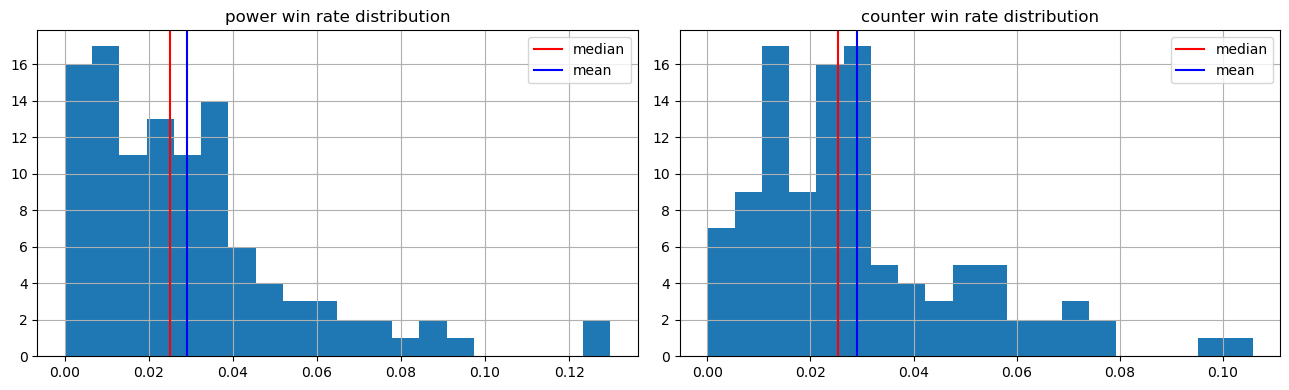

count    108.000000
mean       0.029037
std        0.025665
min        0.000000
25%        0.009830
50%        0.024951
75%        0.037340
max        0.129771
Name: power_win_rate, dtype: float64
count    108.000000
mean       0.029103
std        0.021126
min        0.000000
25%        0.013051
50%        0.025344
75%        0.039344
max        0.105769
Name: counter_win_rate, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label in [
    (axes[0], 'power_win_rate', 'power'),
    (axes[1], 'counter_win_rate', 'counter')
]:
    rankings[col].hist(bins=20, ax=ax)
    ax.axvline(rankings[col].median(), color='red', label='median')
    ax.axvline(rankings[col].mean(), color='blue', label='mean')
    ax.set_title(f'{label} win rate distribution')
    ax.legend()

plt.tight_layout()
plt.show()

print(rankings['power_win_rate'].describe())
print(rankings['counter_win_rate'].describe())

## Validation

In [14]:
top_20_pct = int(len(rankings) * 0.20)
print(f"ROC-AUC: {scores.mean():.3f} — {'PASS' if scores.mean() > 0.60 else 'FAIL'} (threshold: 0.60)")
print(f"Top 20% cutoff: rank ≤ {top_20_pct}")

elite = ['Garrett', 'Bosa', 'Hendrickson', 'Parsons', 'Burns']
for name in elite:
    match = rankings[rankings['displayName'].str.contains(name)]
    if not match.empty:
        rank = match['rank'].values[0]
        print(f"{match['displayName'].values[0]}: rank {rank}/{len(rankings)} — {'✓ top 20%' if rank <= top_20_pct else '✗ outside top 20%'}")

ROC-AUC: 0.623 — PASS (threshold: 0.60)
Top 20% cutoff: rank ≤ 21
Myles Garrett: rank 1/108 — ✓ top 20%
Nick Bosa: rank 5/108 — ✓ top 20%
Trey Hendrickson: rank 4/108 — ✓ top 20%
Micah Parsons: rank 6/108 — ✓ top 20%
Brian Burns: rank 36/108 — ✗ outside top 20%


## Save Output

In [15]:
rankings.to_csv(OUT_DIR / 'edge_rush_player_rankings.csv', index=False)

print("Shape:", rankings.shape)
print("Columns:", rankings.columns.tolist())
print("Unique rushers:", rankings['nflId'].nunique())

Shape: (108, 19)
Columns: ['nflId', 'displayName', 'position', 'teamAbbr', 'total_rushes', 'speed_wins', 'power_wins', 'counter_wins', 'losses', 'adjusted_pressure_rate', 'double_team_rate', 'rank', 'speed_win_rate', 'power_win_rate', 'counter_win_rate', 'speed_index', 'power_index', 'counter_index', 'tier']
Unique rushers: 108
